Key Components:
1. State graph: Tells us the core plan or flow of our application.
2. Planner State: Tells us the state of our planning process.
3. Node Functions: It describes each step of our flow(input city, input interest, create itinerary)
4. LLM Integration: Models used to carry on the itinerary

In [ ]:
!pip install langchain langchain_core langchain_groq langchain-community langchain langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

Define Agent

In [ ]:

class PlannerState(TypedDict):
  messages: Annotated[List[HumanMessage | AIMessage], "The message is in the conversation"]
  city : str
  interests: List[str]
  itinerary : str


In [ ]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    temperature=0,
    groq_api_key="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",
    model_name="llama-3.3-70b-versatile"
)


In [ ]:
itinerary_prompt= ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Create a day trip itinerary for {city} based on the user's interest: {interests}. Provide a bried bulleted itinerary"),
    ("human", "Create an itinerary for a day trip")
])

Define Agent Function

In [ ]:
def input_city(state: PlannerState) -> PlannerState:
  print("Please enter the city you want to visit for your day trip")
  user_message= input("Your input:")
  return {
      **state,
      "city": user_message,
      "messages": state["messages"] + [HumanMessage(content=user_message)]
  }

def input_interest(state: PlannerState) -> PlannerState:
  print(f"Please enter your interests for the trip to: {state["city"]} (comma-seperated):")
  user_message= input("Your input:")
  return {
      **state,
      "interests": [interest.strip() for interest in user_message.split(",")],
      "messages": state["messages"] + [HumanMessage(content=user_message)]
  }

def create_itinerary(state: PlannerState) -> PlannerState:
  print(f"Creating an itinerary for {state['city']} with interests: {','.join(state["interests"])}")
  response= llm.invoke(itinerary_prompt.format(city=state["city"], interests=','.join(state["interests"])))
  print("\nFinal itinerary:")
  print(response.content)
  return {
      **state,
      "messages": state["messages"] + [AIMessage(content=response.content)],
      "itinerary": response.content,
  }

Create and compile the Graph

In [ ]:
workflow= StateGraph( PlannerState)

workflow.add_node ("input_city",input_city)
workflow.add_node("input_interest", input_interest)
workflow.add_node("create_itinerary", create_itinerary)

workflow.set_entry_point("input_city")

workflow.add_edge("input_city", "input_interest")
workflow.add_edge("input_interest", "create_itinerary")
workflow.add_edge("create_itinerary", END)

app = workflow.compile()

Display the Graph structure

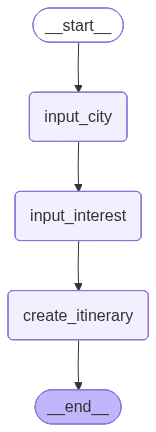

In [ ]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

Define the function that runs the Graph

In [ ]:
def travel_planner(user_request:str):
  print (f"Initial request:{user_request}\n")
  state={
      "messages": [HumanMessage(content=user_request)],
      "city": "",
      "interests": [],
      "itinerary": "",
  }
  for output in app.stream(state):
    pass

In [ ]:
user_request ="I want to plan a day trip"
travel_planner(user_request)

Initial request:I want to plan a day trip

Please enter the city you want to visit for your day trip
Your input:goa
Please enter your interests for the trip to: goa (comma-seperated):
Your input:beaches, historic forts
Creating an itinerary for goa with interests: beaches,historic forts


AuthenticationError: Error code: 401 - {'error': {'message': 'Invalid API Key', 'type': 'invalid_request_error', 'code': 'invalid_api_key'}}

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq

class PlannerState(TypedDict):
  messages: Annotated[List[HumanMessage | AIMessage], "The message is in the conversation"]
  city : str
  interests: List[str]
  itinerary : str

llm = ChatGroq(
    temperature=0,
    groq_api_key="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",
    model_name="llama-3.3-70b-versatile"
)

itinerary_prompt= ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant. Create a day trip itinerary for {city} based on the user's interest: {interests}. Provide a bried bulleted itinerary"),
    ("human", "Create an itinerary for a day trip")
])

def input_city(city: str, state: PlannerState) -> PlannerState:
  return {
      **state,
      "city": city,
      "messages": state["messages"] + [HumanMessage(content=city)],
  }

def input_interest(interests: str, state: PlannerState) -> PlannerState:
  return {
      **state,
      "interests": [interest.strip() for interest in interests.split(',')],
      "messages": state['messages'] + [HumanMessage(content=interests)]
  }

def create_itinerary(state: PlannerState) -> str:
  response= llm.invoke(itinerary_prompt.format_messages(city=state["city"], interests=','.join(state["interests"])))
  state["messages"]= state["messages"] + [AIMessage(content=response.content)]
  state["itinerary"] = response.content
  return response.content

def travel_planner(city:str, interests:str):
  state={
      "messages": [],
      "city": "",
      "interests": [],
      "itinerary": "",
  }

  state= input_city(city, state)
  state= input_interest(interests,state)

  itinerary= create_itinerary(state)

  return itinerary


interface = gr.Interface(
    fn=travel_planner,
    theme='Yntec/HaleyCH_Theme_Orange_Green',
    inputs=[
        gr.Textbox(label="Enter the city for your day trip"),
        gr.Textbox(label="Enter your interests (comma-seperated)"),
    ],
    outputs=
        gr.Textbox(label="Generated Itinerary"),
        title="Travel Itinerary Planner",
        description= "Enter a city and your interest to generate a personalized day trip itinerary"
)
interface.launch()